# Comparer trois ETF qui suivent le même indice

Trois ETF répliquent le STOXX Europe 600. Ils détiennent les mêmes 600 actions,
ou promettent la même performance. Pourtant ils ne finissent pas au même niveau.

Ce notebook mesure l'écart entre eux et teste une hypothèse : **cet écart vient
des frais courants**. Là où l'hypothèse ne tient pas, il cherche pourquoi.

Auteur : KOULEKPOTO Yao Eloge Crédo — septembre 2026

## 1. Périmètre et traitement des données

| Ticker | Émetteur | Place | Frais annuels (TER) | Réplication | Dividendes |
|---|---|---|---|---|---|
| MEUD.PA | Amundi | Euronext Paris | 0,07 % | physique, complète | capitalisant |
| ETZ.PA | BNP Paribas Easy | Euronext Paris | 0,19 % | synthétique (swap) | capitalisant |
| EXSA.DE | iShares | Xetra | 0,20 % | physique, complète | distribuant |

*Source des frais et du mode de réplication : fiches des émetteurs via justETF, septembre 2026.*

**Prix ajustés.** `yf.download()` applique par défaut `auto_adjust=True` : les cours
sont corrigés des dividendes et des divisions d'actions. Sans cette correction, le
détachement d'un dividende ferait apparaître une baisse de prix qui n'est pas une
perte pour le porteur, et un fonds distribuant comme EXSA.DE serait mécaniquement
pénalisé face à deux fonds capitalisants.

In [1]:
import pandas as pd
import yfinance as yf

TICKERS = ["ETZ.PA", "EXSA.DE", "MEUD.PA"]

# Snapshot taken on 2026-09-25. Re-running this cell refreshes the CSV and
# extends the period, so every figure below will change accordingly.
raw = yf.download(TICKERS, start="2023-01-01")

# yf.download returns a two-level column index (field, ticker).
# Only the closing prices are needed here, already adjusted by auto_adjust.
close = raw["Close"]
close.columns.name = None
close.to_csv("data/etf_europe.csv")

close.shape

[*********************100%***********************]  3 of 3 completed


(955, 3)

In [2]:
# How many sessions are missing for each fund?
close.isna().sum()

ETZ.PA       1
EXSA.DE      6
MEUD.PA    290
dtype: int64

**Lecture du diagnostic.** MEUD.PA affiche 289 valeurs manquantes, EXSA.DE 5, ETZ.PA
aucune. Deux causes distinctes :

- **289 lignes** : l'historique Yahoo de MEUD.PA ne remonte pas avant le 19 février 2024,
  le fonds ayant changé d'émetteur et de code. Comparer des performances impose une
  fenêtre identique pour tous : la date de départ est celle du fonds le plus récent,
  et non celle des données disponibles pour chacun.
- **5 lignes** : des jours où l'une des deux places n'a pas coté. Les jours fériés ne
  coïncident pas entre Paris et Francfort.

Un `dropna()` retire les deux d'un coup. Il est préférable à un report du dernier cours
connu : sur une comparaison de performance, une cotation inventée fausse les rendements
de deux séances, celle du trou et la suivante.

In [3]:
# --- Load the snapshot and keep only sessions common to the three funds ---
etf = pd.read_csv("data/etf_europe.csv", index_col="Date", parse_dates=True)
etf = etf.dropna()

print(etf.index.min().date(), "->", etf.index.max().date(), "|", len(etf), "sessions")
etf.head()

2024-02-19 -> 2026-09-25 | 660 sessions


,ETZ.PA,EXSA.DE,MEUD.PA
Date,,,
2024-02-19,15.112,45.084953,223.820007
2024-02-20,15.094,45.010891,223.429993
2024-02-21,15.066,44.936844,223.139999
2024-02-22,15.198,45.353394,225.250000
2024-02-23,15.258,45.501503,226.190002


660 séances retenues sur les 665 disponibles depuis le 19 février 2024.

Les trois fonds suivent le même indice, avec des frais dans un rapport de 1 à 3.
L'écart de performance cumulée devrait donc rester proche de l'écart de frais
cumulé sur la période.

## 2. Performance cumulée, base 100

Diviser chaque série par sa première valeur et multiplier par 100 ramène les trois
fonds à un point de départ commun. Leurs prix unitaires vont de 15 € à 224 € : sans
ce retraitement, les courbes ne seraient pas comparables à l'œil.

In [4]:
# --- Rebase every fund to 100 on the first common session ---
base100 = etf / etf.iloc[0] * 100

# Sanity check: the first row must be exactly 100 everywhere
base100.head(1)

,ETZ.PA,EXSA.DE,MEUD.PA
Date,,,
2024-02-19,100.0,100.0,100.0


<Axes: title={'center': 'Performance cumulée de 3 ETF actions Europe, base 100 (février 2024 - septembre 2026)'}, xlabel='Date', ylabel='Base 100'>

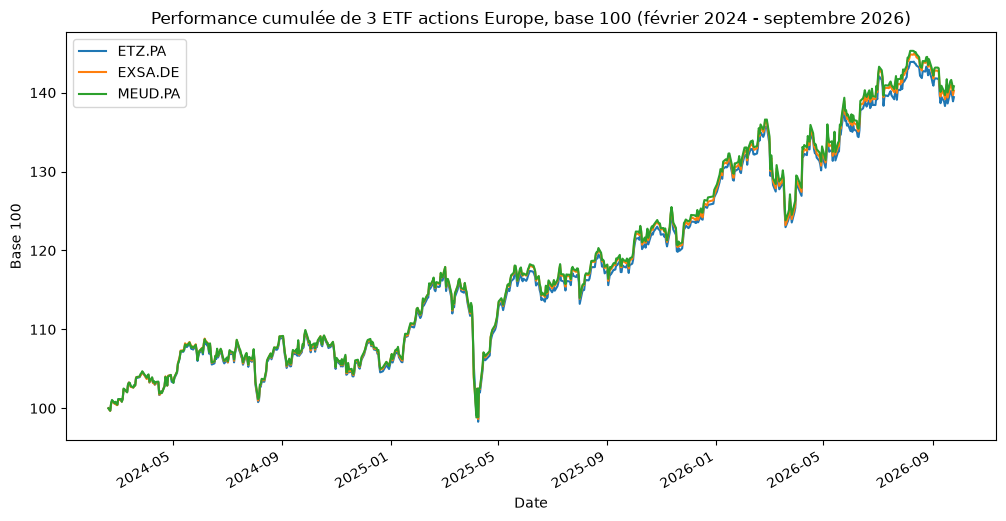

In [5]:
base100.plot(
    figsize=(12, 6),
    title="Performance cumulée de 3 ETF actions Europe, base 100 (février 2024 - septembre 2026)",
    ylabel="Base 100",
)

## 3. L'écart observé face à l'écart attendu

Les frais courants sont prélevés en continu sur l'actif du fonds. Sur une période de
*n* années, l'écart de performance qu'ils expliquent entre deux fonds vaut donc
approximativement :

> (frais A − frais B) × n

Le tableau ci-dessous mesure chaque fonds par rapport au meilleur des trois, et compare
l'écart réellement observé à celui que les frais expliquent. La dernière colonne est le
résultat de l'exercice : ce qui reste inexpliqué.

In [6]:
# --- Observed gap vs gap explained by ongoing charges ---
# Ongoing charges from each issuer's factsheet (justETF, September 2026), in % per year
fees = pd.Series({"ETZ.PA": 0.19, "EXSA.DE": 0.20, "MEUD.PA": 0.07})

n_years = (base100.index[-1] - base100.index[0]).days / 365.25

summary = pd.DataFrame({
    "Cumulative return (%)": base100.iloc[-1] - 100,
    "Ongoing charges (%/y)": fees,
    "Fee drag (pt)": fees * n_years,
})
summary = summary.sort_values("Cumulative return (%)", ascending=False)

# Every fund is measured against the best performer of the three
best = summary["Cumulative return (%)"].max()
summary["Gap vs best (pt)"] = best - summary["Cumulative return (%)"]
summary["Expected from fees (pt)"] = summary["Fee drag (pt)"] - summary["Fee drag (pt)"].min()
summary["Unexplained (pt)"] = summary["Gap vs best (pt)"] - summary["Expected from fees (pt)"]

print(f"Period: {n_years:.2f} years")
summary.round(2)

Period: 2.60 years


,Cumulative return (%),Ongoing charges (%/y),Fee drag (pt),Gap vs best (pt),Expected from fees (pt),Unexplained (pt)
MEUD.PA,40.81,0.07,0.18,0.00,0.00,0.00
EXSA.DE,40.25,0.20,0.52,0.56,0.34,0.22
ETZ.PA,39.43,0.19,0.49,1.38,0.31,1.07


## 4. Conclusion

Trois ETF répliquant le STOXX Europe 600, comparés en base 100 du 19 février 2024 au
25 septembre 2026, soit 660 séances communes.

Sur la période, MEUD.PA gagne 40,81 %, EXSA.DE 40,25 % et ETZ.PA 39,43 %. L'écart entre
le meilleur et le moins bon atteint 1,38 point de pourcentage, pour des fonds censés
suivre les mêmes 600 actions.

**Hypothèse testée** : cet écart s'explique par les frais courants (0,07 % pour MEUD,
0,19 % pour ETZ, 0,20 % pour EXSA).

**Elle tient pour EXSA.DE.** Ses frais supérieurs de 0,13 point par an lui coûtent
0,34 point sur 2,60 ans ; l'écart observé est de 0,56 point. Même ordre de grandeur,
0,22 point résiduel.

**Elle ne tient pas pour ETZ.PA.** Ses frais n'expliquent que 0,31 point, alors que
l'écart observé atteint 1,38 point. Il reste 1,07 point sans explication — plus de
trois fois ce que les frais justifient.

**Piste.** ETZ.PA est le seul des trois à réplication synthétique. Le fonds ne détient
pas les actions de l'indice : il échange la performance d'un panier contre celle du
STOXX Europe 600 auprès d'une contrepartie bancaire. Le coût de ce contrat est prélevé
à l'intérieur du swap et n'apparaît donc pas dans les frais courants affichés. L'écart
entre la performance d'un fonds et celle de son indice porte un nom, la *tracking
difference*, et les frais courants n'en sont qu'une composante.

**Ce qui permettrait de trancher** : le rapport annuel du fonds, qui détaille le coût
du swap, et une comparaison directe de chaque fonds avec l'indice STOXX Europe 600 Net
Return plutôt qu'entre fonds.

### Limites

- Trois ETF seulement, et une fenêtre de 2,6 ans : trop court pour distinguer un écart
  structurel d'un effet de période.
- Les frais retenus sont ceux affichés en septembre 2026 et supposés constants sur toute
  la période.
- Les prix de clôture de Paris et de Francfort ne sont pas relevés à la même seconde.
  Sur des performances cumulées de plus de deux ans, l'effet est négligeable ; il ne le
  serait pas sur une comparaison de volatilité journalière.